<a href="https://colab.research.google.com/github/SutamaSarkar/RealiabilitySimulation/blob/main/loadsharing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import matplotlib.pyplot as plt
import math

In [5]:
lamda=00.001
lamdastar=0.003
Analytical_reliability_100 =( 3 * math.exp(-0.002 * 100)) - (2 * math.exp(-0.003 * 100))
Analytical_reliability_1000 =( 3 * math.exp(-0.002 * 1000)) - (2 * math.exp(-0.003 * 1000))
print("Analytical Reliability for 100 hr is = ",Analytical_reliability_100)
print("Analytical Reliability for 1000 hr is = ",Analytical_reliability_1000)

Analytical Reliability for 100 hr is =  0.9745558178705098
Analytical Reliability for 1000 hr is =  0.3064317129741102



TRIALS(N)	Reliability_100	Reliability_1000
-----------------------------------------------------------------------
100			0.9800			0.2700
1000			0.9780			0.3350
10000			0.9768			0.3078
100000			0.9742			0.3052
1000000			0.9747			0.3065
-----------------------------------------------------------------------


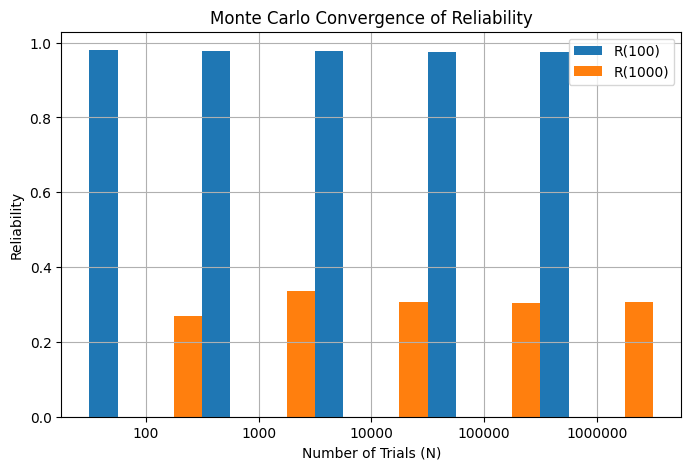

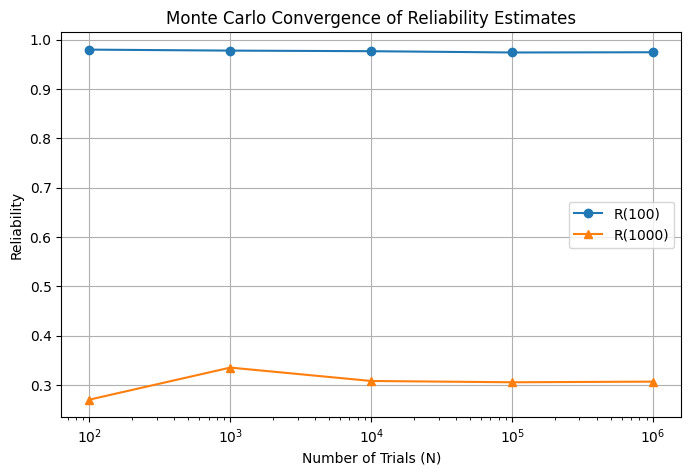

In [10]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

trial_list=[100,1000,10000,100000,1000000]

N_list=[]
Rel_100_list=[]
Rel_1000_list=[]

lamda=0.001
lamdastar=0.003


print("\nTRIALS(N)\tReliability_100\tReliability_1000")
print("-----------------------------------------------------------------------")

for N in trial_list:

    sum_1=0
    sum_2=0


    for i in range(N):
       Fa=random.uniform(0,1)
       Fb=random.uniform(0,1)

       ta=-math.log(1-Fa)/(2*lamda)
       tb=-math.log(1-Fb)/(lamdastar)
       t_total=ta+tb

       if t_total>100:
        sum_1=sum_1+1
       if t_total>1000:
        sum_2=sum_2+1

    probability_1=sum_1/N
    probability_2=sum_2/N

    N_list.append(N)
    Rel_100_list.append(probability_1)
    Rel_1000_list.append(probability_2)
    print(f"{N}\t\t\t{probability_1:.4f}\t\t\t{probability_2:.4f}")

print("-----------------------------------------------------------------------")
x=np.arange(len(N_list))
width=0.25

plt.figure(figsize=(8,5))

plt.bar(x - 1.5*width, Rel_100_list, width, label="R(100)")

plt.bar(x + 1.5*width, Rel_1000_list, width, label="R(1000)")

plt.xticks(x,N_list)

plt.xlabel("Number of Trials (N)")
plt.ylabel("Reliability")
plt.title("Monte Carlo Convergence of Reliability")

plt.legend()
plt.grid(True)

plt.show()


# ---------- BAR CHART ----------

plt.figure(figsize=(8,5))

plt.plot(N_list,Rel_100_list,marker='o',label="R(100)")

plt.plot(N_list,Rel_1000_list,marker='^',label="R(1000)")

plt.xscale("log")   # log scale shows convergence clearly

plt.xlabel("Number of Trials (N)")
plt.ylabel("Reliability")
plt.title("Monte Carlo Convergence of Reliability Estimates")

plt.legend()
plt.grid(True)

plt.show()